# Importing Dependencies

In [292]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns


# Data Collection and Preprocessing

In [293]:
# Loading data

calorie_data = pd.read_csv('calories.csv')
exercise_data = pd.read_csv('exercise.csv')

In [294]:
calorie_data.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [295]:
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


Combining Two Data Frames

In [296]:
calorie_data = pd.concat([exercise_data, calorie_data['Calories']], axis=1)

In [297]:
# First five rows

calorie_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [298]:
# No of rows and cols

calorie_data.shape

(15000, 9)

In [299]:
calorie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [300]:
# Get statistical details

calorie_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


# Data Visualization

In [301]:
sns.set()

In [302]:
calorie_data['Gender'].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Gender'>

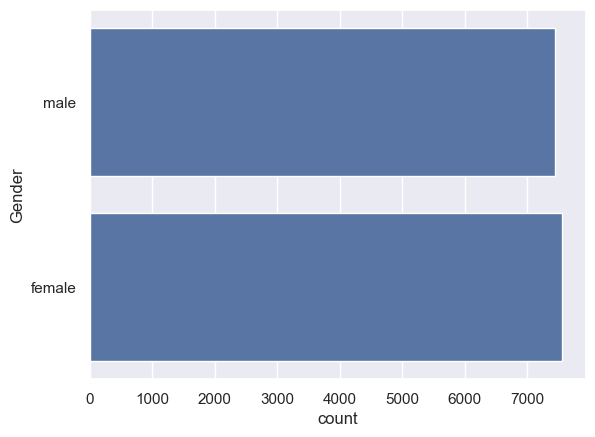

In [303]:
# Plotting gender col in count plot
sns.countplot(calorie_data['Gender'])

C:\Users\abbas\AppData\Local\Temp\ipykernel_10612\1831909204.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calorie_data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

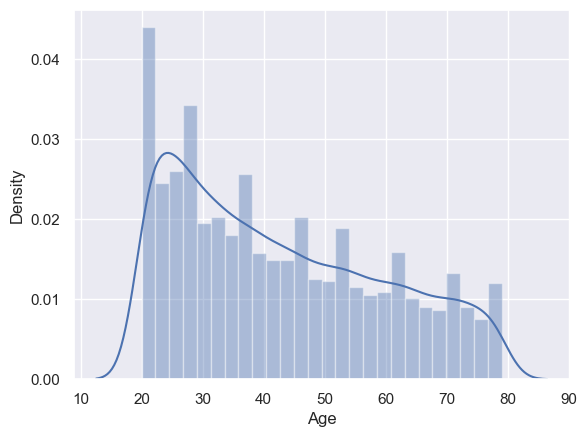

In [304]:
# Distribtion of age

sns.distplot(calorie_data['Age'])

C:\Users\abbas\AppData\Local\Temp\ipykernel_10612\3474985237.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calorie_data['Height'])


<Axes: xlabel='Height', ylabel='Density'>

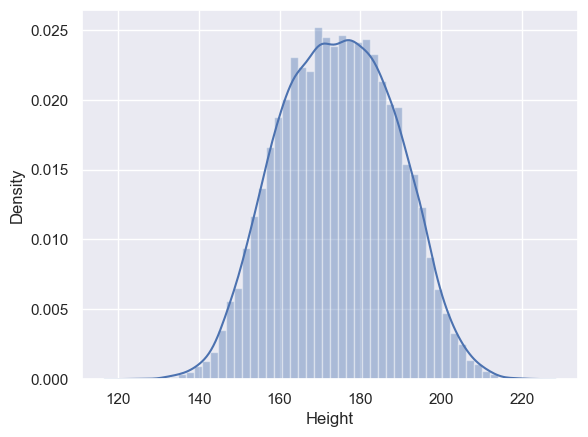

In [305]:
# Distribution on Height

sns.distplot(calorie_data['Height'])

C:\Users\abbas\AppData\Local\Temp\ipykernel_10612\1384790612.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calorie_data['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

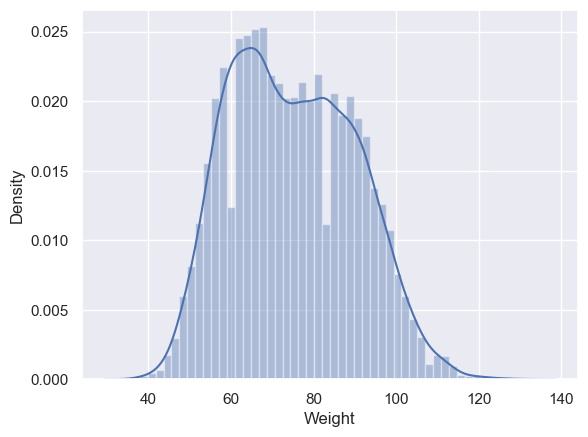

In [306]:
# Distribution on weight

sns.distplot(calorie_data['Weight'])

Finding Correlation in the Dataset

1. Positive Correlation
2. Negative Correlation

In [307]:
# Calculate correlation only for numeric columns
correlation = calorie_data.corr(numeric_only=True)

<Axes: >

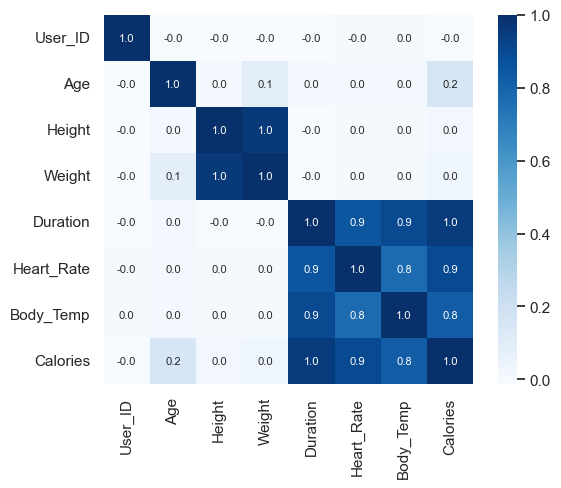

In [308]:
# Constructing a heatmap

plt.Figure(figsize=(6,6))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

Converting Text Data into numericals

In [309]:
calorie_data.replace({"Gender":{"male":0, "female":1}}, inplace=True)

C:\Users\abbas\AppData\Local\Temp\ipykernel_10612\2584731274.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calorie_data.replace({"Gender":{"male":0, "female":1}}, inplace=True)


In [310]:
calorie_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


# Splitting Features and Target

In [311]:
X = calorie_data.drop(columns='Calories')
Y = calorie_data['Calories']

In [312]:
print(X)

        User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0      14733363       0   68   190.0    94.0      29.0       105.0       40.8
1      14861698       1   20   166.0    60.0      14.0        94.0       40.3
2      11179863       0   69   179.0    79.0       5.0        88.0       38.7
3      16180408       1   34   179.0    71.0      13.0       100.0       40.5
4      17771927       1   27   154.0    58.0      10.0        81.0       39.8
...         ...     ...  ...     ...     ...       ...         ...        ...
14995  15644082       1   20   193.0    86.0      11.0        92.0       40.4
14996  17212577       1   27   165.0    65.0       6.0        85.0       39.2
14997  17271188       1   43   159.0    58.0      16.0        90.0       40.1
14998  18643037       0   78   193.0    97.0       2.0        84.0       38.3
14999  11751526       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 8 columns]


In [313]:
print(Y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


# Splitting Data into Training and Test Data

In [314]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [315]:
print(X.shape, X_train.shape, X_test.shape)

(15000, 8) (12000, 8) (3000, 8)


# Model Training

In [316]:
Model = XGBRegressor()

In [317]:
Model.fit(X_train, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Model Evaluation

In [318]:

# Test data prediction 
test_data_prediction = Model.predict(X_test)

mae_test= mean_absolute_error(Y_test, test_data_prediction)

print("Mean Absolute Error on Test Data", mae_test)

Mean Absolute Error on Test Data 1.57148710261782
